In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os
os.makedirs('/content/drive/MyDrive/hotel_lab', exist_ok=True)
print("Drive ready.")


Mounted at /content/drive
Drive ready.


#MODULE 3 — Clean & Preprocess

#Class 1 — Load and LOOK first

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/hotel_lab/hotel_reviews_europe.csv')
print("Full shape:", df.shape)

Full shape: (515738, 17)


In [ ]:
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [ ]:
df = df.sample(100_000, random_state=42).reset_index(drop=True)
print("Sample shape:", df.shape)
df.head()


Sample shape: (100000, 17)


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,Via Senigallia 6 20161 Milan Italy,904,7/21/2017,8.1,Hotel Da Vinci,United Kingdom,Would have appreciated a shop in the hotel th...,52,16670,Hotel was great clean friendly staff free bre...,62,1,9.6,"[' Leisure trip ', ' Couple ', ' Double Room '...",13 days,45.533137,9.171102
1,Arlandaweg 10 Westpoort 1043 EW Amsterdam Neth...,612,12/12/2016,8.6,Urban Lodge Hotel,Belgium,No tissue paper box was present at the room,10,5018,No Positive,0,7,8.8,"[' Leisure trip ', ' Group ', ' Triple Room ',...",234 day,52.385649,4.834443
2,Mallorca 251 Eixample 08008 Barcelona Spain,46,11/26/2015,8.3,Alexandra Barcelona A DoubleTree by Hilton,Sweden,Pillows,3,351,Nice welcoming and service,5,15,7.9,"[' Business trip ', ' Solo traveler ', ' Twin ...",616 day,41.393192,2.161520
3,Piazza Della Repubblica 17 Central Station 201...,241,10/17/2015,9.1,Hotel Principe Di Savoia,United States of America,No Negative,0,1543,Everything including the nice upgrade The Hot...,27,9,10.0,"[' Leisure trip ', ' Couple ', ' Ambassador Ju...",656 day,45.479888,9.196298
4,Singel 303 309 Amsterdam City Center 1012 WJ A...,834,5/16/2016,9.1,Hotel Esther a,United Kingdom,No Negative,0,4687,Lovely hotel v welcoming staff,7,2,9.6,"[' Business trip ', ' Solo traveler ', ' Class...",444 day,52.370545,4.888644


#Class 2 — Fix the broken days_since_review column

In [ ]:
print("Before:", df['days_since_review'].head(3).tolist())
df['days_since_review'] = (df['days_since_review']
                           .str.replace(' days', '', regex=False)
                           .str.replace(' day', '', regex=False)
                           .astype(int))
print("After:", df['days_since_review'].head(3).tolist())

Before: ['13 days', '234 day', '616 day']
After: [13, 234, 616]


#Class 3 — Handle missing lat / lng

In [ ]:
print("Missing lat:", df['lat'].isnull().sum())
print("Missing lng:", df['lng'].isnull().sum())

df['lat'] = df['lat'].fillna(df['lat'].median())
df['lng'] = df['lng'].fillna(df['lng'].median())

print("Missing after fill:", df[['lat','lng']].isnull().sum().sum())


Missing lat: 644
Missing lng: 644
Missing after fill: 0


#Class 4 — Drop the text columns we will not use

In [ ]:
text_cols = ['Hotel_Address', 'Hotel_Name', 'Reviewer_Nationality',
             'Negative_Review', 'Positive_Review', 'Tags', 'Review_Date']
df = df.drop(columns=text_cols)
print("Columns now:", df.columns.tolist())


Columns now: ['Additional_Number_of_Scoring', 'Average_Score', 'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews', 'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'days_since_review', 'lat', 'lng']


#Class 5 — Choose the final feature list

In [ ]:
feature_columns = [
    'Additional_Number_of_Scoring', 'Average_Score',
    'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews',
    'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given',
    'days_since_review', 'lat', 'lng'
]
print("Number of features:", len(feature_columns))
df[feature_columns].describe().round(2)


Number of features: 9


,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,days_since_review,lat,lng
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,497.17,8.40,18.49,2740.87,17.73,7.12,354.79,49.45,2.81
std,501.20,0.55,29.70,2320.85,22.01,10.97,209.09,3.46,4.58
min,1.00,5.20,0.00,43.00,0.00,1.00,0.00,41.33,-0.37
25%,169.00,8.10,2.00,1158.00,5.00,1.00,176.00,48.21,-0.14
50%,338.00,8.40,9.00,2130.00,11.00,3.00,354.00,51.50,0.02
75%,641.00,8.80,23.00,3613.00,22.00,8.00,528.00,51.52,4.83
max,2682.00,9.80,402.00,16670.00,383.00,315.00,730.00,52.40,16.43


#Class 6 — Save the clean file (your Module 3 deliverable)

In [ ]:
final_df = df[feature_columns + ['Reviewer_Score']].copy()
final_df.insert(0, 'review_id', range(len(final_df)))

print("Final shape:", final_df.shape)
final_df.to_parquet('/content/drive/MyDrive/hotel_lab/hotel_clean.parquet')
print("Saved hotel_clean.parquet — your Module 3 deliverable!")


Final shape: (100000, 11)
Saved hotel_clean.parquet — your Module 3 deliverable!


#MODULE 4 — Train & Evaluate

#Class 7 — Load the clean file and split

In [ ]:

df = pd.read_parquet('/content/drive/MyDrive/hotel_lab/hotel_clean.parquet')

feature_columns = [
    'Additional_Number_of_Scoring', 'Average_Score',
    'Review_Total_Negative_Word_Counts', 'Total_Number_of_Reviews',
    'Review_Total_Positive_Word_Counts', 'Total_Number_of_Reviews_Reviewer_Has_Given',
    'days_since_review', 'lat', 'lng'
]
X = df[feature_columns]
y = df['Reviewer_Score']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


#Class 8 — Scale, then train TWO models

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn the scale FROM TRAIN ONLY
X_test  = scaler.transform(X_test)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

model1 = LinearRegression()
model1.fit(X_train, y_train)

model2 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model2.fit(X_train, y_train)
print("Both models trained.")


Both models trained.


# Class 9 — Evaluate (the most important step)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

for name, model in [("Linear Regression", model1), ("Random Forest", model2)]:
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"\n=== {name} ===")
    print("MAE :", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R2  :", round(r2, 3))



=== Linear Regression ===
MAE : 1.05
RMSE: 1.37
R2  : 0.307

=== Random Forest ===
MAE : 0.96
RMSE: 1.28
R2  : 0.391


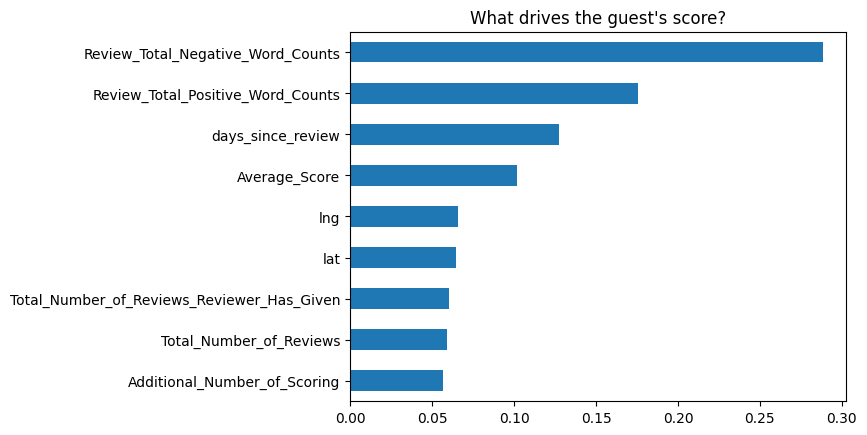

Review_Total_Negative_Word_Counts    0.288268
Review_Total_Positive_Word_Counts    0.175580
days_since_review                    0.127669
Average_Score                        0.101678
lng                                  0.065924
dtype: float64


In [ ]:
importance = pd.Series(model2.feature_importances_, index=feature_columns)
importance.sort_values().plot.barh(title="What drives the guest's score?")
plt.show()
print(importance.sort_values(ascending=False).head(5))

# **Answers**

1).MAE is 0.96 and RMSE is 1.28 — that's a noticeable gap. Since RMSE punishes large errors more heavily, this gap means the model is usually about 1 point off, but occasionally makes big mistakes of 3–4 points. Those rare large errors push RMSE up while MAE stays low

2).Average_Score is the hotel's overall rating — an average of thousands of guests, almost always between 7–9. It barely changes, so it tells the model very little about this specific guest's experience.
Negative_Review word count is personal — if a guest writes a long complaint, they are clearly unhappy. If they write nothing, they are probably fine. It directly reflects how this individual guest feels, which is exactly what we are trying to predict.

3). Not really. If a guest actually scores 4, the model could predict anywhere from 3 to 5. If it predicts 5, Emma sees a "normal" guest and takes no action — but the guest is actually unhappy. For early intervention, you would need either a more accurate model or a safety threshold like "flag anyone predicted below 6, just in case.